In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

In [2]:
Pc_des = 1.5e5

In [3]:
R = 8.314  # J/(mol.K). It is the ideal gas constant.
M_H2O = 18.01528e-3  # kg/mol. It
epsilon_gdl = 0.5 
epsilon_c = 0.3
gamma_cond = 5e3  # s-1. It is the overall condensation rate constant for water.
gamma_evap = 1e-4  # Pa-1.s-1. It is the overall evaporation rate constant for water.
theta_c_gdl = 120 * np.pi / 180  # radian. It is the contact angle of GDL for liquid water.
Psat = lambda T: 101325 * 10 ** (-2.1794 + 0.02953 * (T - 273.15) - 9.1837e-5 * (T - 273.15) ** 2 + 1.4454e-7 * (T - 273.15) ** 3)

def rho_H2O(T):
    return ((999.83952 + 16.945176 * (T - 273.15) - 7.9870401e-3 * (T - 273.15) ** 2 - 46.170461e-6 * (T - 273.15) ** 3
                 + 105.56302e-9 * (T - 273.15) ** 4 - 280.54253e-12 * (T - 273.15) ** 5) /
                (1 + 16.879850e-3 * (T - 273.15)))
def sigma(T):
    return 235.8e-3 * ((647.15 - T) / 647.15) ** 1.256 * (1 - 0.625 * (647.15 - T) / 647.15)
def K0(epsilon, epsilon_c, epsilon_gdl):
    if epsilon_gdl < 0.67:
        beta1 = -3.60
    else:
        beta1 = -2.60
    return epsilon / (8 * np.log(epsilon) ** 2) * (epsilon - 0.11) ** (0.785 + 2) * 4.6e-6 ** 2 / ((1 - 0.11) ** 0.785 * ((0.785 + 1) * epsilon - 0.11) ** 2) * np.exp(beta1 * epsilon_c)
def nu_l(T):
    mu_l = 2.414 * 10 ** (-5 + 247.8 / (T - 140.0))  # Pa.s. It is the liquid water dynamic viscosity.
    return mu_l / rho_H2O(T)

def Svl(s, C_v, Ctot, epsilon, T):
    C_v_sat = Psat(T)/(R * T)
    if C_v >= C_v_sat:  # condensation
            return gamma_cond * epsilon * (1 - s) * (C_v / Ctot) * (C_v - C_v_sat)
    else:  # evaporation
            return -gamma_evap * epsilon * s * rho_H2O(T) / M_H2O * R * T * (C_v_sat - C_v)
    
K0_gdl = K0(epsilon_gdl, epsilon_c, epsilon_gdl)

In [4]:
def compare_e(e):
        s_ccl = 0.6

        def Ds_gdl(s_gdl, T_gdl):
                Ds = - sigma(T_gdl) * K0_gdl / nu_l(T_gdl) * abs(np.cos(theta_c_gdl)) * (epsilon_gdl / K0_gdl) ** 0.5 * \
                        (s_gdl ** e + 1e-7) * (1.417 - 4.24 * s_gdl + 3.789 * s_gdl ** 2)
                return Ds
        
        def ODE_PEMFC(x, y):
                n_points = x.size
                dydx = np.zeros_like(y)
                # Extract state variables from y
                s = y[0,:]
                Js = y[1,:]
                # Calculate derivatives 
                ds = np.zeros_like(x)
                # Calculate derivatives for fluxes
                dJs = np.zeros_like(x)
                for i_node in range(n_points):
                        ds[i_node] = -Js[i_node] / (rho_H2O(333.15) * 0.6) / Ds_gdl(s[i_node], 333.15)
                        dJs[i_node] = Svl(s[i_node], Psat(333.15)/(R * 333.15), Pc_des, epsilon_gdl, 333.15)
                dydx[0,:] = ds
                dydx[1,:] = dJs

                return dydx

        def boundary_condition(ya, yb):
                return np.array([ya[0] - 0.01, yb[0] - 0.])
        
        x_mesh = np.linspace(0, 2e-4, 10)
        y_init = np.zeros((2, x_mesh.size))
        s_init = [s_ccl - i*s_ccl/10 for i in range(10)]
        js_init = [0 for i in range(10)]
        y_init[0, :] = s_init
        y_init[1, :] = js_init
        sol = solve_bvp(ODE_PEMFC, boundary_condition, x_mesh, y_init, tol=1e-6, max_nodes=5000)
        print("Success:", sol.success)
        return sol

Success: True
Success: True
Success: True


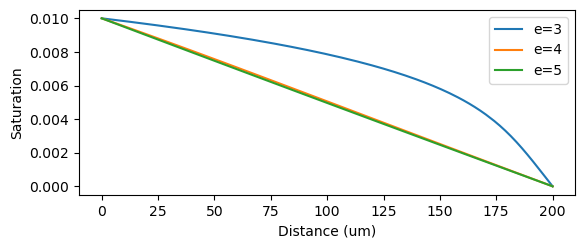

In [5]:
fig, ax = plt.subplots(figsize=(6.4, 2.4))
for e in [3,4,5]:
    sol = compare_e(e)
    ax.plot(sol.x * 1e6, sol.y[0, :], label=f'e={e}')
ax.set_xlabel('Distance (um)')
ax.set_ylabel('Saturation')
ax.legend()